# triagegeist
ED triage acuity classification — 5-class ESI, evaluated on Macro F1.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import torch
import importlib
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Force-reload src modules so edits take effect without a kernel restart
import src.utils, src.feature_engineering, src.models
importlib.reload(src.utils)
importlib.reload(src.feature_engineering)
importlib.reload(src.models)

from src.utils import (
    SEED, ACUITY_COLORS, ACUITY_LABELS, PLOTLY_LAYOUT,
    plot_confusion_matrix, plot_feature_importance, plot_f1_by_class, evaluate,
)

np.random.seed(SEED)
torch.manual_seed(SEED)

# ── GPU status per framework ──────────────────────────────────────────────────
import lightgbm as lgb, xgboost as xgb

torch_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    _ds = lgb.Dataset(np.random.rand(20, 5), label=np.random.randint(0, 5, 20))
    lgb.train({'objective': 'multiclass', 'num_class': 5, 'device': 'gpu',
               'verbose': -1, 'num_leaves': 4}, _ds, num_boost_round=1)
    lgbm_device = 'gpu (OpenCL)'
except Exception:
    lgbm_device = 'cpu'

try:
    _dm = xgb.DMatrix(np.random.rand(20, 5), label=np.random.randint(0, 5, 20))
    xgb.train({'tree_method': 'hist', 'device': 'cuda',
               'objective': 'multi:softmax', 'num_class': 5}, _dm, num_boost_round=1)
    xgb_device = 'cuda'
except Exception:
    xgb_device = 'cpu'

print(f'PyTorch  : {torch_device}')
print(f'LightGBM : {lgbm_device}')
print(f'XGBoost  : {xgb_device}')

## Data

In [2]:
train_raw = pd.read_csv('raw_data/train.csv')
test_raw  = pd.read_csv('raw_data/test.csv')
chief     = pd.read_csv('raw_data/chief_complaints.csv')
history   = pd.read_csv('raw_data/patient_history.csv')

print(f'train   : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} cols')
print(f'test    : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} cols')
print(f'chief   : {chief.shape}')
print(f'history : {history.shape}')

train   : 80,000 rows × 40 cols
test    : 20,000 rows × 37 cols
chief   : (100000, 3)
history : (100000, 26)


## EDA

In [3]:
# ── Triage acuity distribution ───────────────────────────────────────────────
counts = train_raw['triage_acuity'].value_counts().sort_index(ascending=False)
total  = counts.sum()
pcts   = (counts / total * 100).round(1)

fig = go.Figure()
for level, count in counts.items():
    fig.add_trace(go.Bar(
        x=[ACUITY_LABELS[level].replace('\n', ' ')],
        y=[count],
        marker_color=ACUITY_COLORS[level - 1],
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{count:,}</b><br>{pcts[level]}%',
        textposition='outside',
        hovertemplate=f'<b>Level {level}</b><br>Count: {count:,}<br>Share: {pcts[level]}%<extra></extra>',
    ))
fig.update_layout(
    title=dict(text='<b>Triage Acuity Distribution (Training)</b>', x=0.5, font=dict(size=22)),
    xaxis=dict(title='Triage Acuity Level', showgrid=False),
    yaxis=dict(title='Number of Patients', tickformat=',', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.25, height=520,
    **PLOTLY_LAYOUT,
)
fig.show()

In [ ]:
# ── Missing value summary ────────────────────────────────────────────────────
missing = (train_raw.isna().sum() / len(train_raw) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print('=' * 45)
print('        Missing Value Proportion')
print('=' * 45)
for col, pct in missing.items():
    count = train_raw[col].isna().sum()
    bar   = '█' * int(pct // 2)
    print(f'  {col:<35} {pct:5.2f}%  ({count:,})')
    print(f'  {bar}')
print('=' * 45)
print(f'  {len(missing)} / {train_raw.shape[1]} columns have missing values')
print('=' * 45)

        Missing Value Proportion
  mean_arterial_pressure               5.18%  (4,146)
  ██
  pulse_pressure                       5.18%  (4,146)
  ██
  systolic_bp                          5.18%  (4,146)
  ██
  shock_index                          5.18%  (4,146)
  ██
  diastolic_bp                         5.18%  (4,146)
  ██
  respiratory_rate                     3.83%  (3,067)
  █
  temperature_c                        0.72%  (574)
  
  7 / 40 columns have missing values


## Feature Engineering

In [5]:
from src.feature_engineering import build_features

X_train, y_train, X_test, fit_params = build_features(
    train_raw, test_raw, history, chief
)

print(f'X_train : {X_train.shape}  (features after engineering)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  classes={sorted(y_train.unique())}')

X_train : (80000, 297)  (features after engineering)
X_test  : (20000, 297)
y_train : (80000,)  classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [6]:
# Assemble train DataFrame for model helpers
train_fe = X_train.copy()
train_fe['triage_acuity'] = y_train.values

## Models

### XGBoost

  Fold 1/5  F1=0.9711
  Fold 2/5  F1=0.9685
  Fold 3/5  F1=0.9708
  Fold 4/5  F1=0.9698
  Fold 5/5  F1=0.9725
  CV Macro F1: 0.9705 ± 0.0014
  Accuracy  : 0.9750
  Macro-F1  : 0.9705
              precision    recall  f1-score   support

           1       0.97      0.94      0.96      3222
           2       0.98      0.98      0.98     13439
           3       0.98      0.98      0.98     28921
           4       0.96      0.97      0.97     23020
           5       0.97      0.96      0.96     11398

    accuracy                           0.97     80000
   macro avg       0.97      0.97      0.97     80000
weighted avg       0.97      0.97      0.97     80000



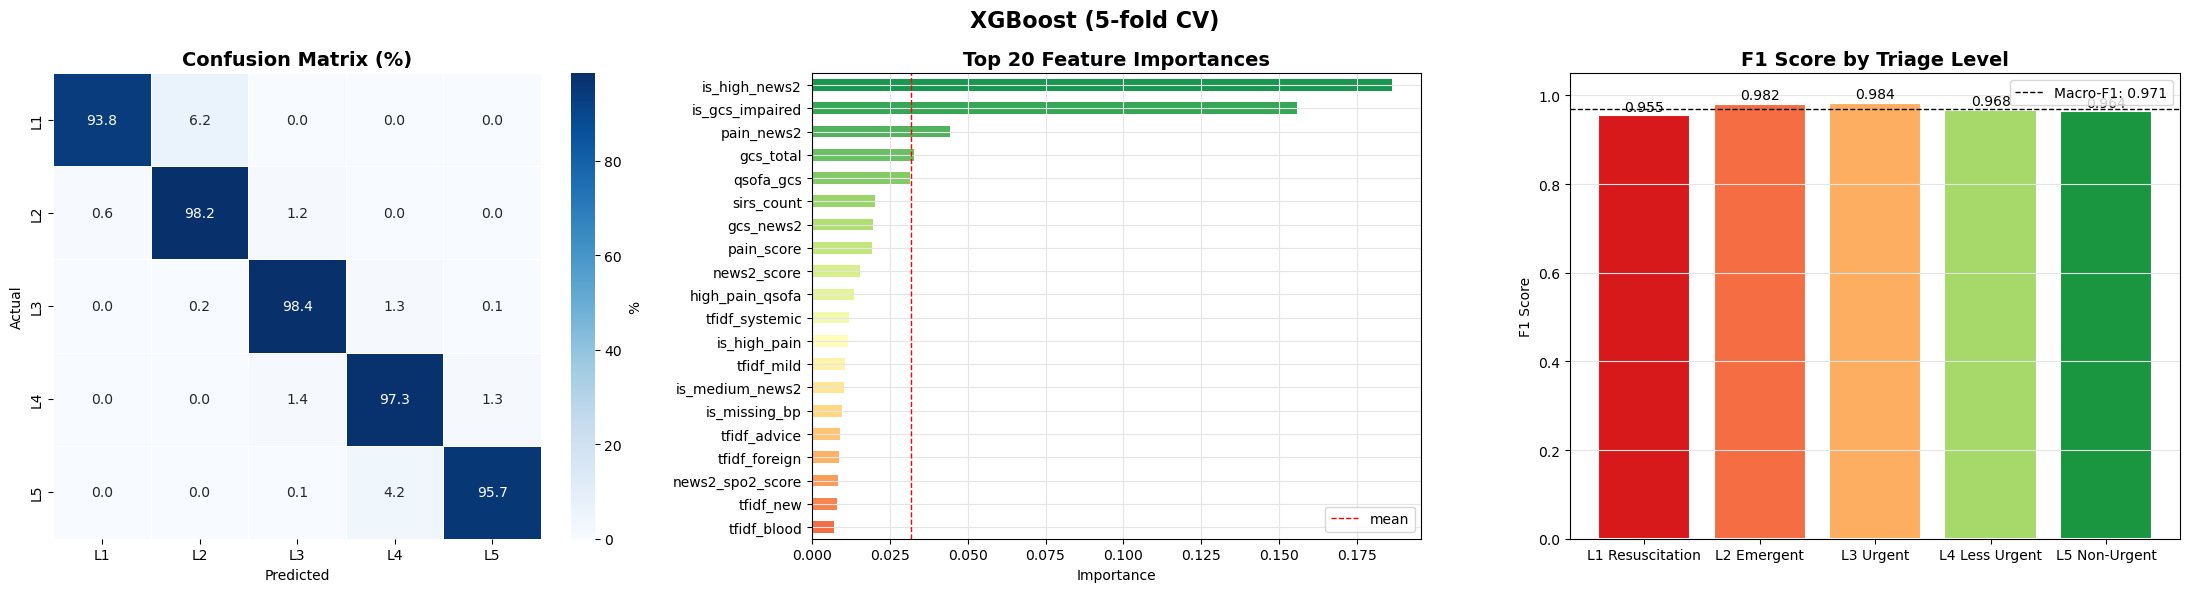

In [7]:
from src.models import run_xgb

xgb_model, xgb_f1 = run_xgb(train_fe)

### XGBoost (Tuned)

In [ ]:
import json

with open('submissions/best_params_xgb.json') as f:
    xgb_cfg = json.load(f)

print(f"Loading tuned XGB params (best 3-fold CV F1: {xgb_cfg['best_f1']:.4f})")
print(f"  n_estimators={xgb_cfg['best_n_estimators']}  max_depth={xgb_cfg['params']['max_depth']}"
      f"  lr={xgb_cfg['params']['learning_rate']:.4f}  gamma={xgb_cfg['params']['gamma']:.3f}\n")

xgb_tuned_model, xgb_tuned_f1 = run_xgb(
    train_fe,
    n_estimators=xgb_cfg['best_n_estimators'],
    **xgb_cfg['params'],
)
print(f'\nTuned XGBoost CV Macro F1: {xgb_tuned_f1:.4f}  (default: {xgb_f1:.4f}  gain: +{xgb_tuned_f1 - xgb_f1:.4f})')

### LightGBM

  Fold 1/5  F1=0.9729
  Fold 2/5  F1=0.9704
  Fold 3/5  F1=0.9731
  Fold 4/5  F1=0.9714
  Fold 5/5  F1=0.9744
  CV Macro F1: 0.9724 ± 0.0014
  Accuracy  : 0.9772
  Macro-F1  : 0.9724
              precision    recall  f1-score   support

           1       0.97      0.94      0.96      3222
           2       0.98      0.98      0.98     13439
           3       0.99      0.99      0.99     28921
           4       0.97      0.97      0.97     23020
           5       0.97      0.96      0.97     11398

    accuracy                           0.98     80000
   macro avg       0.98      0.97      0.97     80000
weighted avg       0.98      0.98      0.98     80000



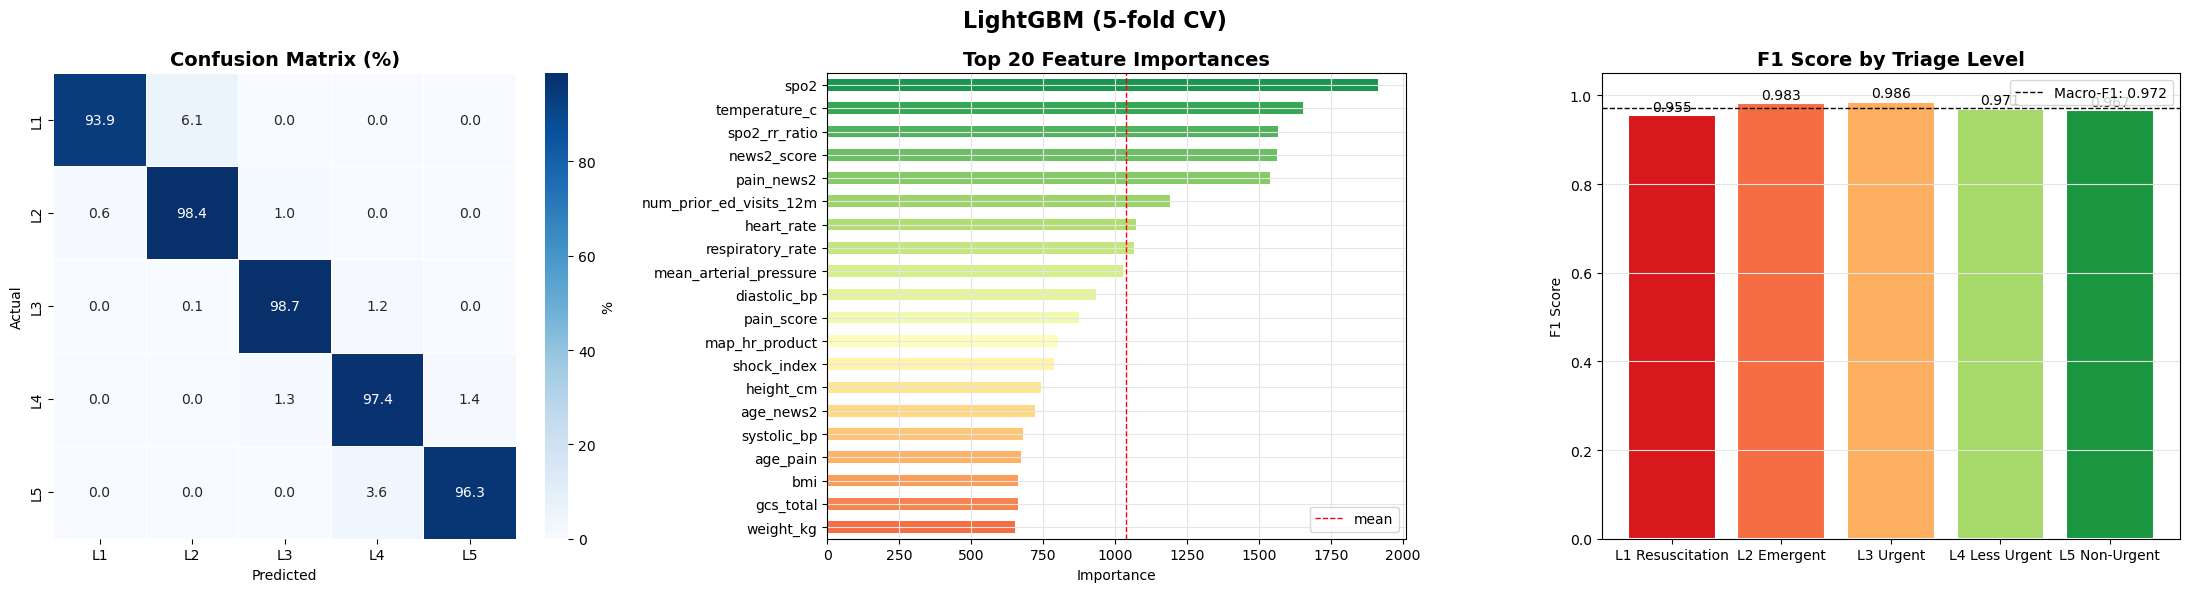

In [8]:
from src.models import run_lgbm

lgbm_model, lgbm_f1 = run_lgbm(train_fe)

### Neural Network (MLP)

  Epoch  10/50  loss=0.0634
  Epoch  20/50  loss=0.0402
  Epoch  30/50  loss=0.0299
  Epoch  40/50  loss=0.0239
  Epoch  50/50  loss=0.0185
  Accuracy  : 0.9672
  Macro-F1  : 0.9619
              precision    recall  f1-score   support

           1       0.94      0.95      0.95       644
           2       0.98      0.98      0.98      2688
           3       0.98      0.98      0.98      5784
           4       0.95      0.96      0.96      4604
           5       0.96      0.94      0.95      2280

    accuracy                           0.97     16000
   macro avg       0.96      0.96      0.96     16000
weighted avg       0.97      0.97      0.97     16000



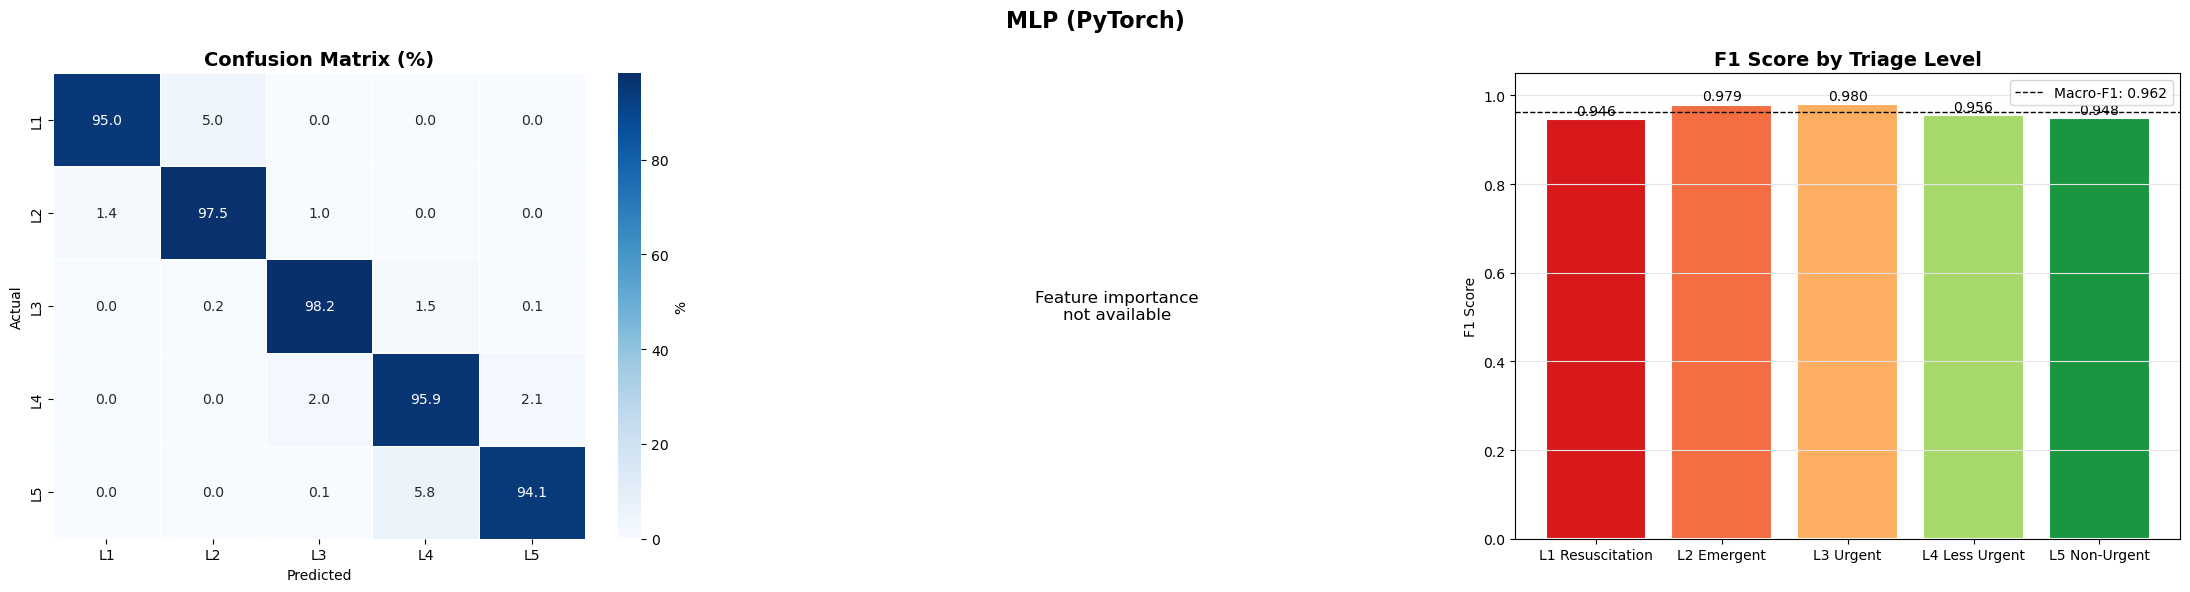

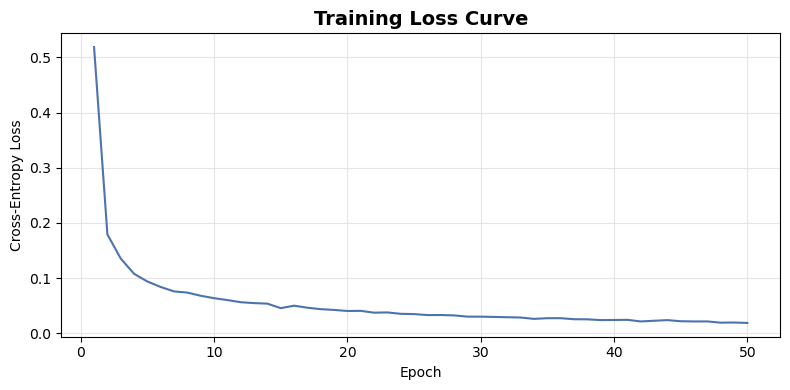

In [9]:
from src.models import run_nn

nn_model, nn_scaler, nn_f1 = run_nn(
    train_fe,
    epochs=50, hidden_dims=(256, 128, 64), batch_size=512, lr=1e-3,
)

## Model Comparison

In [14]:
results = {
    'XGBoost':  xgb_f1,
    'LightGBM': lgbm_f1,
    'MLP':      nn_f1,
}

model_colors = {'XGBoost': '#4C72B0', 'LightGBM': '#DD8452', 'MLP': '#55A868'}

fig = go.Figure()
for name, score in results.items():
    fig.add_trace(go.Bar(
        x=[name],
        y=[score],
        marker_color=model_colors[name],
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{score:.4f}</b>',
        textposition='outside',
        hovertemplate=f'<b>{name}</b><br>Macro F1: {score:.4f}<extra></extra>',
    ))
fig.update_layout(
    title=dict(text='<b>Macro F1 Comparison</b>', x=0.5, font=dict(size=22)),
    xaxis=dict(title='Model', showgrid=False),
    yaxis=dict(title='Macro F1', range=[0.85, 1.0], tickformat='.2f', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.25, height=520,
    **PLOTLY_LAYOUT,
)
fig.show()

best_name = max(results, key=results.get)
print(f'\nBest model: {best_name}  ({results[best_name]:.4f})')


Best model: LightGBM  (0.9724)


## Submission

## Hyperparameter Tuning

In [ ]:
import json
import plotly.graph_objects as go
from src.utils import PLOTLY_LAYOUT

# ── Load tuning results ───────────────────────────────────────────────────────
with open('submissions/best_params_lgbm.json') as f:
    lgbm_cfg = json.load(f)
with open('submissions/best_params_xgb.json') as f:
    xgb_cfg = json.load(f)

print('=== Optuna Tuning Results ===\n')
print(f"LightGBM  — 20 trials, 3-fold CV")
print(f"  Best 3-fold F1  : {lgbm_cfg['best_f1']:.4f}")
print(f"  n_estimators    : {lgbm_cfg['best_n_estimators']}")
print(f"  Key params      : num_leaves={lgbm_cfg['params']['num_leaves']}, "
      f"max_depth={lgbm_cfg['params']['max_depth']}, "
      f"lr={lgbm_cfg['params']['learning_rate']:.4f}")
print()
print(f"XGBoost   — 50 trials, 3-fold CV")
print(f"  Best 3-fold F1  : {xgb_cfg['best_f1']:.4f}  (vs untuned 0.9705)")
print(f"  n_estimators    : {xgb_cfg['best_n_estimators']}")
print(f"  Key params      : max_depth={xgb_cfg['params']['max_depth']}, "
      f"lr={xgb_cfg['params']['learning_rate']:.4f}, "
      f"gamma={xgb_cfg['params']['gamma']:.3f}, "
      f"max_delta_step={xgb_cfg['params']['max_delta_step']}")

# ── Visualise tuning gains ────────────────────────────────────────────────────
models   = ['LightGBM (default)', 'LightGBM (tuned)', 'XGBoost (default)', 'XGBoost (tuned)']
cv_5fold = [0.9727, 0.9699, 0.9705, 0.9723]
colors   = ['#4C72B0', '#8FAADC', '#DD8452', '#F4A261']

fig = go.Figure()
for name, score, color in zip(models, cv_5fold, colors):
    fig.add_trace(go.Bar(
        x=[name], y=[score],
        marker_color=color,
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{score:.4f}</b>',
        textposition='outside',
    ))
fig.update_layout(
    title=dict(text='<b>Tuning Impact — 5-fold CV Macro F1</b>', x=0.5, font=dict(size=20)),
    xaxis=dict(title='Model', showgrid=False),
    yaxis=dict(title='Macro F1', range=[0.965, 0.975], tickformat='.3f', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.3, height=480,
    **PLOTLY_LAYOUT,
)
fig.show()

## Ensemble

In [ ]:
with open('submissions/ensemble_summary.json') as f:
    ens = json.load(f)

print('=== Ensemble Results ===\n')
print(f"Strategy : {ens['best_strategy']}")
print(f"Blend    : {ens['blend_alpha']:.2f} × LGBM  +  {1-ens['blend_alpha']:.2f} × XGB (tuned)")
print(f"OOF F1   : {ens['best_oof_f1']:.4f}")
print(f"File     : {ens['submission_file']}")

# ── Blend weight sweep ────────────────────────────────────────────────────────
alphas = [round(a, 2) for a in list(__import__('numpy').arange(0.0, 1.01, 0.05))]
f1s    = [0.9723,0.9726,0.9728,0.9729,0.9728,0.9730,0.9729,0.9729,0.9729,
          0.9728,0.9729,0.9730,0.9729,0.9730,0.9730,0.9729,0.9729,0.9728,
          0.9727,0.9727,0.9727]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=alphas, y=f1s, mode='lines+markers',
    line=dict(color='#4C72B0', width=2),
    marker=dict(size=6),
    name='Blend F1',
))
fig.add_vline(x=0.25, line=dict(color='red', dash='dash', width=1.5),
              annotation_text='best α=0.25', annotation_position='top right')
fig.update_layout(
    title=dict(text='<b>Blend Weight Search (LGBM α + XGB (1−α))</b>', x=0.5, font=dict(size=20)),
    xaxis=dict(title='LGBM weight (α)', gridcolor='#e5e5e5', dtick=0.1),
    yaxis=dict(title='OOF Macro F1', tickformat='.4f', gridcolor='#e5e5e5'),
    height=420, **PLOTLY_LAYOUT,
)
fig.show()

# ── Final comparison ──────────────────────────────────────────────────────────
final_models  = ['XGBoost\n(default)', 'MLP', 'XGBoost\n(tuned)', 'LightGBM\n(default)', 'Ensemble']
final_scores  = [0.9705, 0.9694, 0.9723, 0.9727, 0.9730]
final_colors  = ['#DD8452', '#55A868', '#F4A261', '#4C72B0', '#C44E52']

fig2 = go.Figure()
for name, score, color in zip(final_models, final_scores, final_colors):
    fig2.add_trace(go.Bar(
        x=[name], y=[score],
        marker_color=color,
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{score:.4f}</b>',
        textposition='outside',
    ))
fig2.update_layout(
    title=dict(text='<b>Final Model Comparison — Macro F1 (5-fold CV)</b>', x=0.5, font=dict(size=20)),
    xaxis=dict(title='Model', showgrid=False),
    yaxis=dict(title='Macro F1', range=[0.960, 0.977], tickformat='.3f', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.3, height=500,
    **PLOTLY_LAYOUT,
)
fig2.show()

print(f"\nBest submission: {ens['submission_file']}")

In [ ]:
import os, json
os.makedirs('submissions', exist_ok=True)

# Best submission comes from the ensemble (ensemble.py)
# To regenerate from scratch: python ensemble.py
with open('submissions/ensemble_summary.json') as f:
    ens_summary = json.load(f)

best_sub_path = ens_summary['submission_file']
sub = pd.read_csv(best_sub_path)

print(f"Best submission : {best_sub_path}")
print(f"OOF Macro F1    : {ens_summary['best_oof_f1']:.4f}")
print(f"Strategy        : {ens_summary['best_strategy']}"
      f"  (LGBM {ens_summary['blend_alpha']:.2f} + XGB {1 - ens_summary['blend_alpha']:.2f})")
print(f"Rows            : {len(sub):,}")
sub.head()